In [1]:
import sys
sys.path.append("/home/carloabrate/iii/src")

In [2]:
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [3]:
import pandas as pd
from utils import  provide_x_z, train_xgb_simple, convert_scores_to_ranks, preprocessing_data
from sklearn.model_selection import KFold
from crt_cgan import ConditionalGAN, crt_calibration_efficient
import numpy as np
from tqdm.notebook import tqdm

In [5]:
from methods import (condor_score, nkci_score, nhsic_score, kcondor_score, cmi_score, 
                     hsic_hyppo_score, partial_dcorr_score, pdnhsic_v2, 
                     Kcondor_v2, Kcondor_v2_opt, Kcondor_v2_opt2, Kcondor_v2_precomputed_factory,
                     Kcondor_v3, kci_pval, nhsic, partial_corr_pg_score)

In [6]:
methods ={
    "Condor": Kcondor_v2,#Kcondor_v2_precomputed_factory, #,
    "nKCI": nkci_score,
    'nhsic': nhsic,
    'cmi_score': cmi_score, 
    'partial_dcorr_score': partial_corr_pg_score#partial_dcorr_score
    ##'kci_pval': kci_pval,
    }

In [7]:
K = 5
linspace_dim = 7
betas = np.linspace(0., 1, linspace_dim)
B = 200
#features_Z = [['African_American'],['Female'],['random']]
dataset_name = "adults"#"propublica"  # 
s_size = 500

In [8]:
if dataset_name == "adults":
    data_path = "/home/carloabrate/iii/data/adult.csv"
    y_name = 'income'
    features_Z = [['gender'],['race'],['random']]
elif dataset_name == "propublica":
    data_path = "/home/carloabrate/iii/data/propublica_data_for_fairml.csv"
    y_name = 'Two_yr_Recidivism'
    features_Z = [['African_American'],['Female'],['random']]
df_all = pd.read_csv(data_path)
print(df_all.shape)

(48842, 15)


In [9]:
#for i,f_p in enumerate(features_Z):
f_p = features_Z[0]

In [10]:
df_all.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [11]:
df_p = preprocessing_data(df_all, 
                          y_name=y_name,
                          dataset_name=dataset_name)

In [12]:
df_p.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,Non-Bachelors,7,Not-Married,Black,Male,0,0,40,1,0
1,38,Private,89814,Non-Bachelors,9,Married,White,Male,0,0,50,1,0
2,28,Non-Private,336951,Non-Bachelors,12,Married,White,Male,0,0,40,1,1
3,44,Private,160323,Non-Bachelors,10,Married,Black,Male,7688,0,40,1,1
4,18,Non-Private,103497,Non-Bachelors,10,Not-Married,White,Female,0,0,30,1,0


In [13]:
# add a random column continous with values between 0 and 1
df_p['random'] = np.random.rand(df_p.shape[0])

In [14]:
# get X, Z, y for the balanced sample
X_np, Z_np, y, X_np_all, Z_np_all, y_all = provide_x_z(df_p, y_name=y_name, f_p=f_p, sample_size_per_class=s_size)
# train a ranking model on the entire dataset
print(f"Training dei modelli di ranking per features {f_p}...")
model_o = train_xgb_simple(pd.DataFrame(X_np_all), y_all)["model"]
model_p = train_xgb_simple(pd.DataFrame(Z_np_all), y_all)["model"]
preds_o = model_o.predict_proba(pd.DataFrame(X_np))[:,1]
preds_p = model_p.predict_proba(pd.DataFrame(Z_np))[:,1]

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'race', 'gender', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income', 'random'],
      dtype='object')
Training dei modelli di ranking per features ['gender']...
Utilizzo di XGBoost con device='cuda'


/home/carloabrate/det-int/lib/python3.12/site-packages/xgboost/core.py:729: UserWarning: [13:16:06] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Utilizzo di XGBoost con device='cuda'


In [15]:
# train K cGAN generators
kf = KFold(n_splits=K, shuffle=True, random_state=42)
kf_splits = list(kf.split(X_np))
print(f"Pre-addestramento di {K} generatori cGAN per il dataset...")
trained_generators = []
for train_idx, _ in tqdm(kf_splits, desc="Training generators"):
    generator = ConditionalGAN(x_dim=X_np.shape[1], z_dim=Z_np.shape[1])
    generator.fit(X_np[train_idx], Z_np[train_idx])
    trained_generators.append(generator)
print("Addestramento completato.")


results = {name: [] for name in methods}
for beta in tqdm(betas, desc="Beta Loop"):
    R = convert_scores_to_ranks((1 - beta) * preds_o + beta * preds_p)
    #sss = (1 - beta) * preds_o + beta * preds_p
    for name, func in methods.items():
        p_val = crt_calibration_efficient(X_np, Z_np, R, scoring_function=func, kf_splits=kf_splits, trained_generators=trained_generators, B=B)
        results[name].append(p_val)

Pre-addestramento di 5 generatori cGAN per il dataset...


Training generators:   0%|          | 0/5 [00:00<?, ?it/s]

Addestramento completato.


Beta Loop:   0%|          | 0/7 [00:00<?, ?it/s]

In [16]:
results_df = pd.DataFrame(results, index=betas).rename_axis(index='Beta', columns='Method')

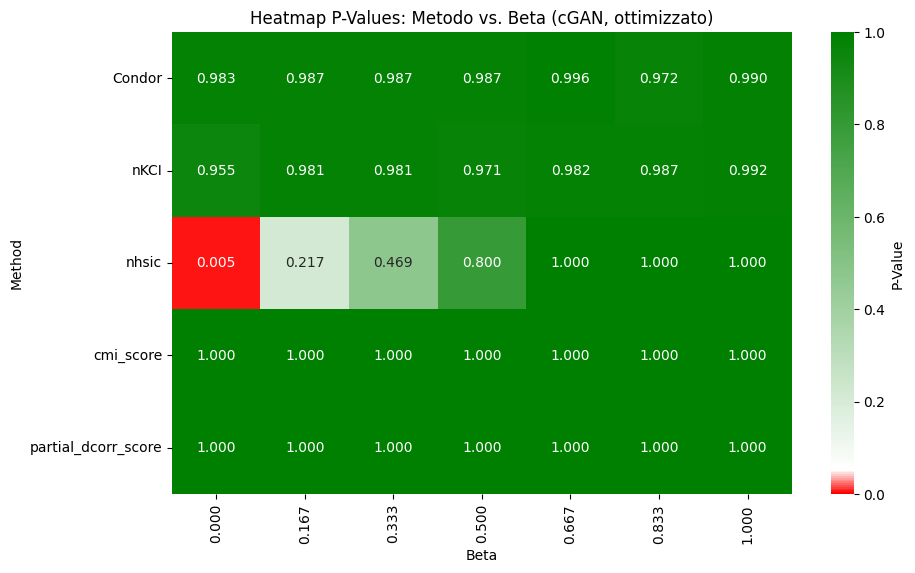

In [17]:
custom_cmap = LinearSegmentedColormap.from_list(
    "pvalue_cmap",
    [(0.0, "red"), (0.05, "white"), (1.0, "green")]
    )
plt.figure(figsize=(10, 6))
ax = sns.heatmap(results_df.T, annot=True, cmap=custom_cmap, fmt=".3f", vmin=0, vmax=1, cbar_kws={'label': 'P-Value'})
ax.set_xticklabels([f"{beta:.3f}" for beta in betas])
plt.title('Heatmap P-Values: Metodo vs. Beta (cGAN, ottimizzato)')
plt.show()

In [ ]:
# save results_all to pickle
import pickle
with open(f"exp_betas_dataset_name_{dataset_name}_f_p_{f_p[0]}_B_{B}_K_{K}_betas_{linspace_dim}_size_{s_size}.pkl", "wb") as f:
    pickle.dump(results_df, f)